In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as m_dates
import warnings 
warnings.filterwarnings("ignore", category = FutureWarning)
from pmdarima import auto_arima

from statsmodels.tsa.statespace.sarimax import SARIMAX

In [30]:
df = pd.read_csv('Downloads/Nat_Gas.csv', parse_dates=['Dates'], date_format='%m/%d/%y')
df = df.set_index('Dates')

In [31]:
df

,Prices
Dates,
2020-10-31,10.10
2020-11-30,10.30
2020-12-31,11.00
2021-01-31,10.90
2021-02-28,10.90
2021-03-31,10.90
2021-04-30,10.40
2021-05-31,9.84
2021-06-30,10.00


In [32]:
print(df.index.dtype)

datetime64[ns]


Natural Gas Price Visualizations

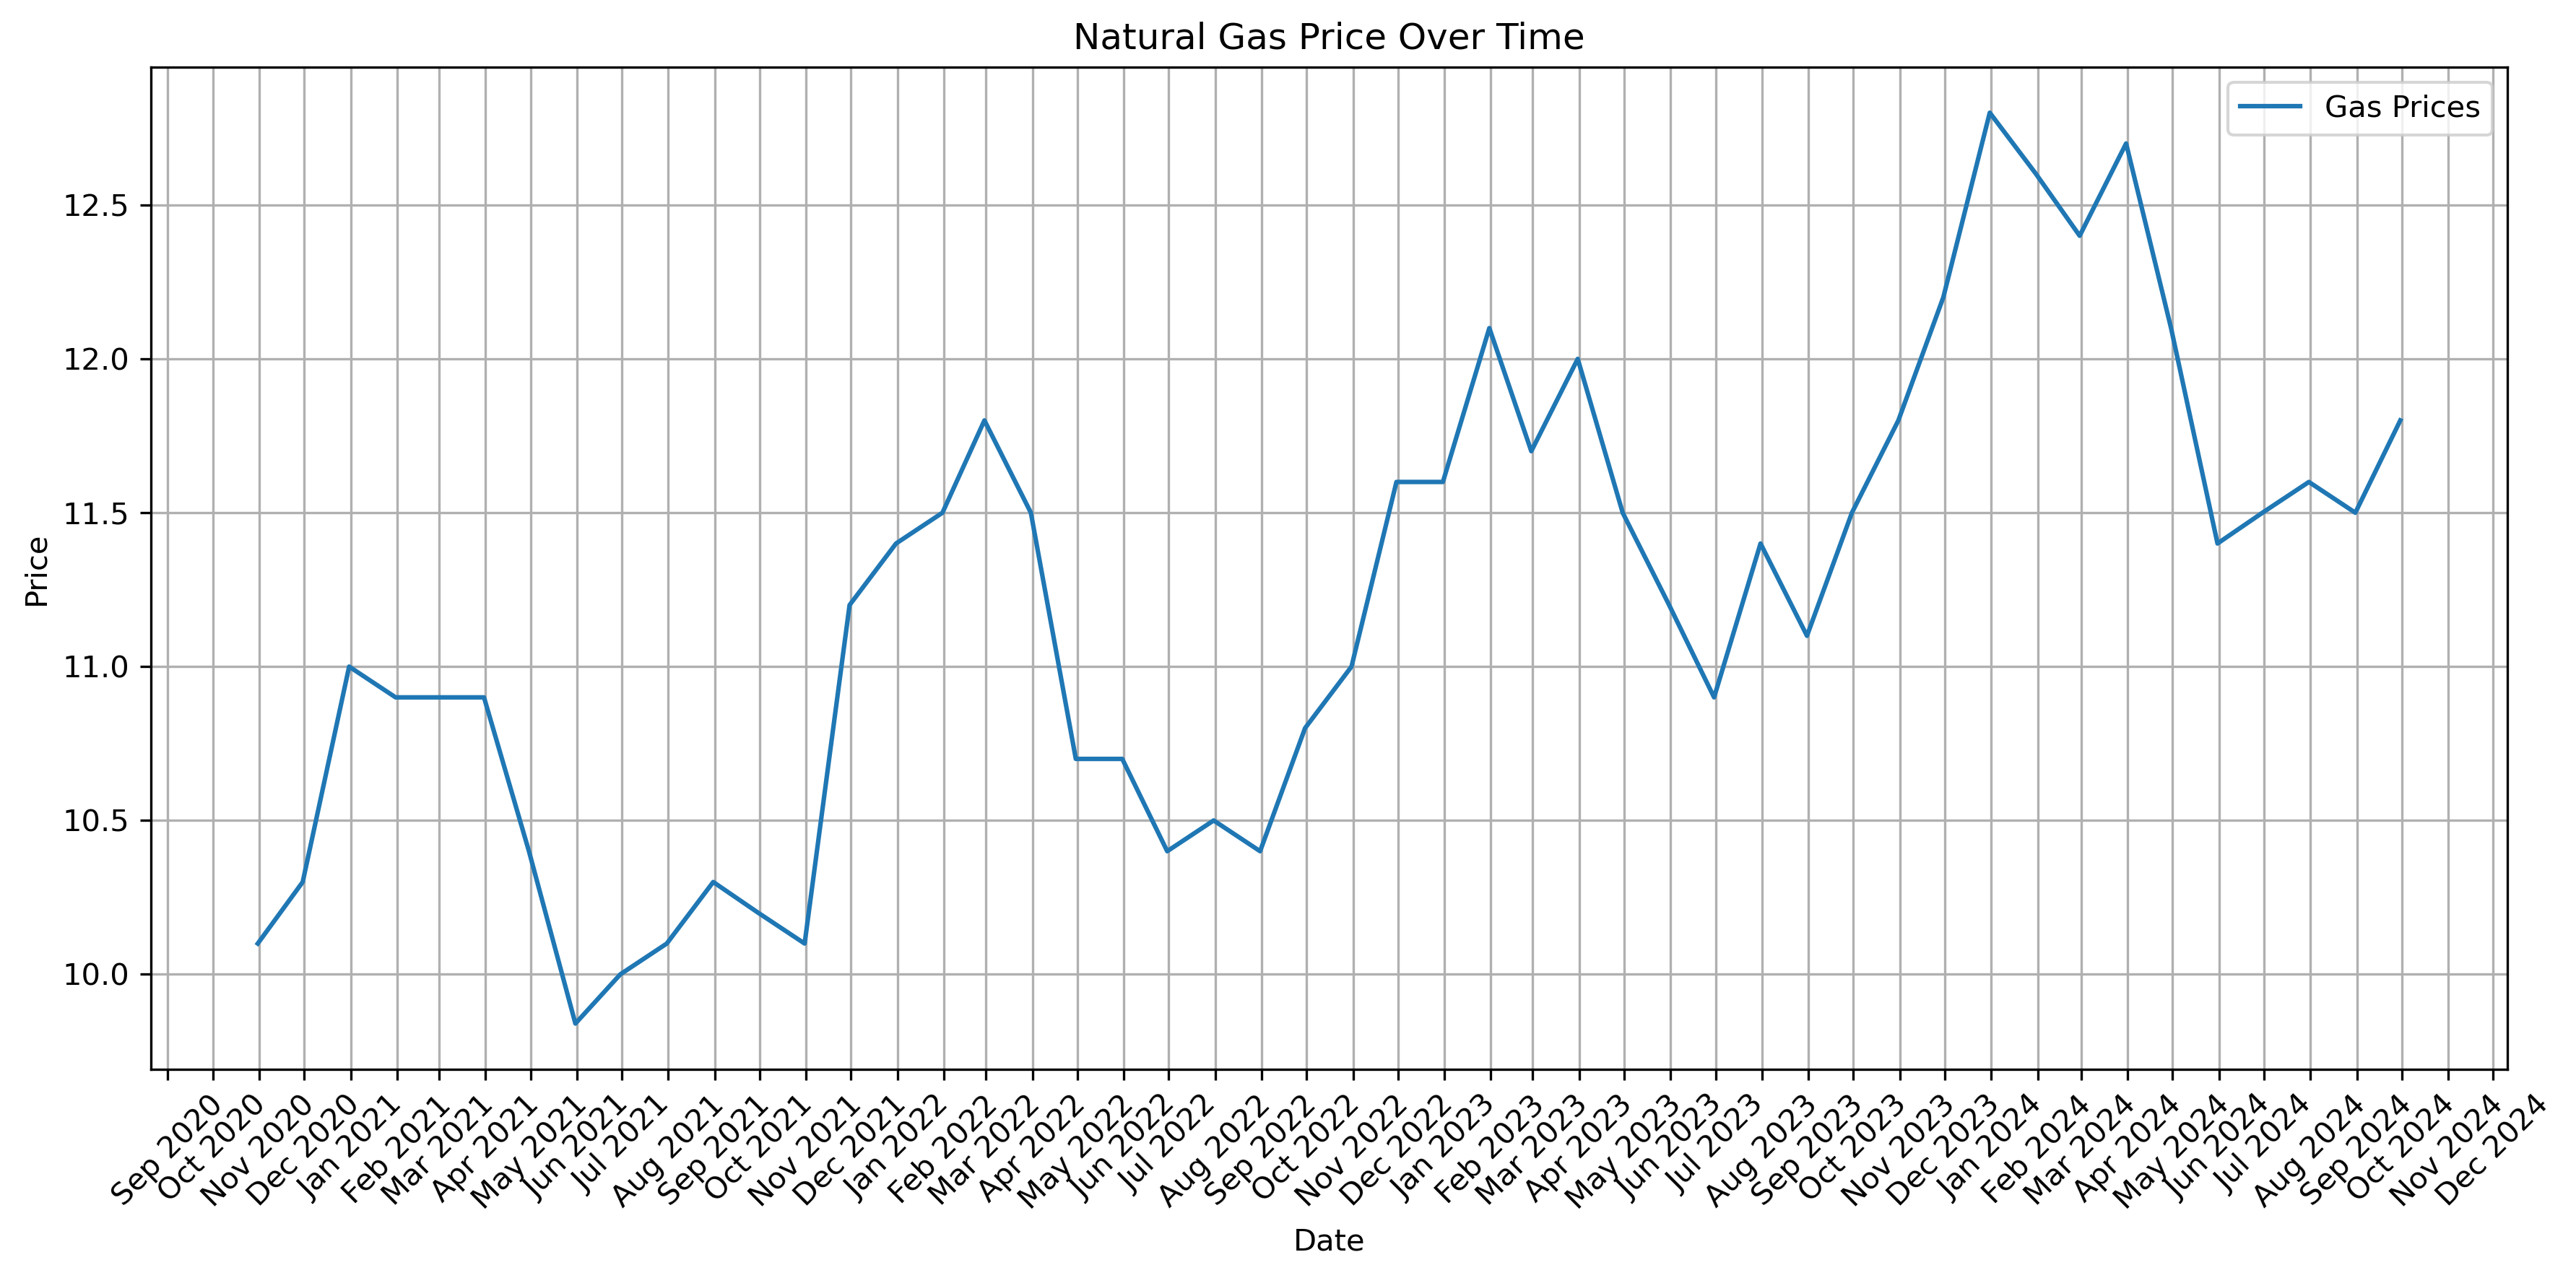

In [33]:
plt.figure(figsize=(12,6) ,dpi=300)
plt.plot(df.index,df['Prices'],label = 'Gas Prices')

plt.title('Natural Gas Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.legend()

#format x-axis ticls by month 
plt.gca().xaxis.set_major_locator(m_dates.MonthLocator(interval=1)) 
plt.gca().xaxis.set_major_formatter(m_dates.DateFormatter('%b %Y')) 

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

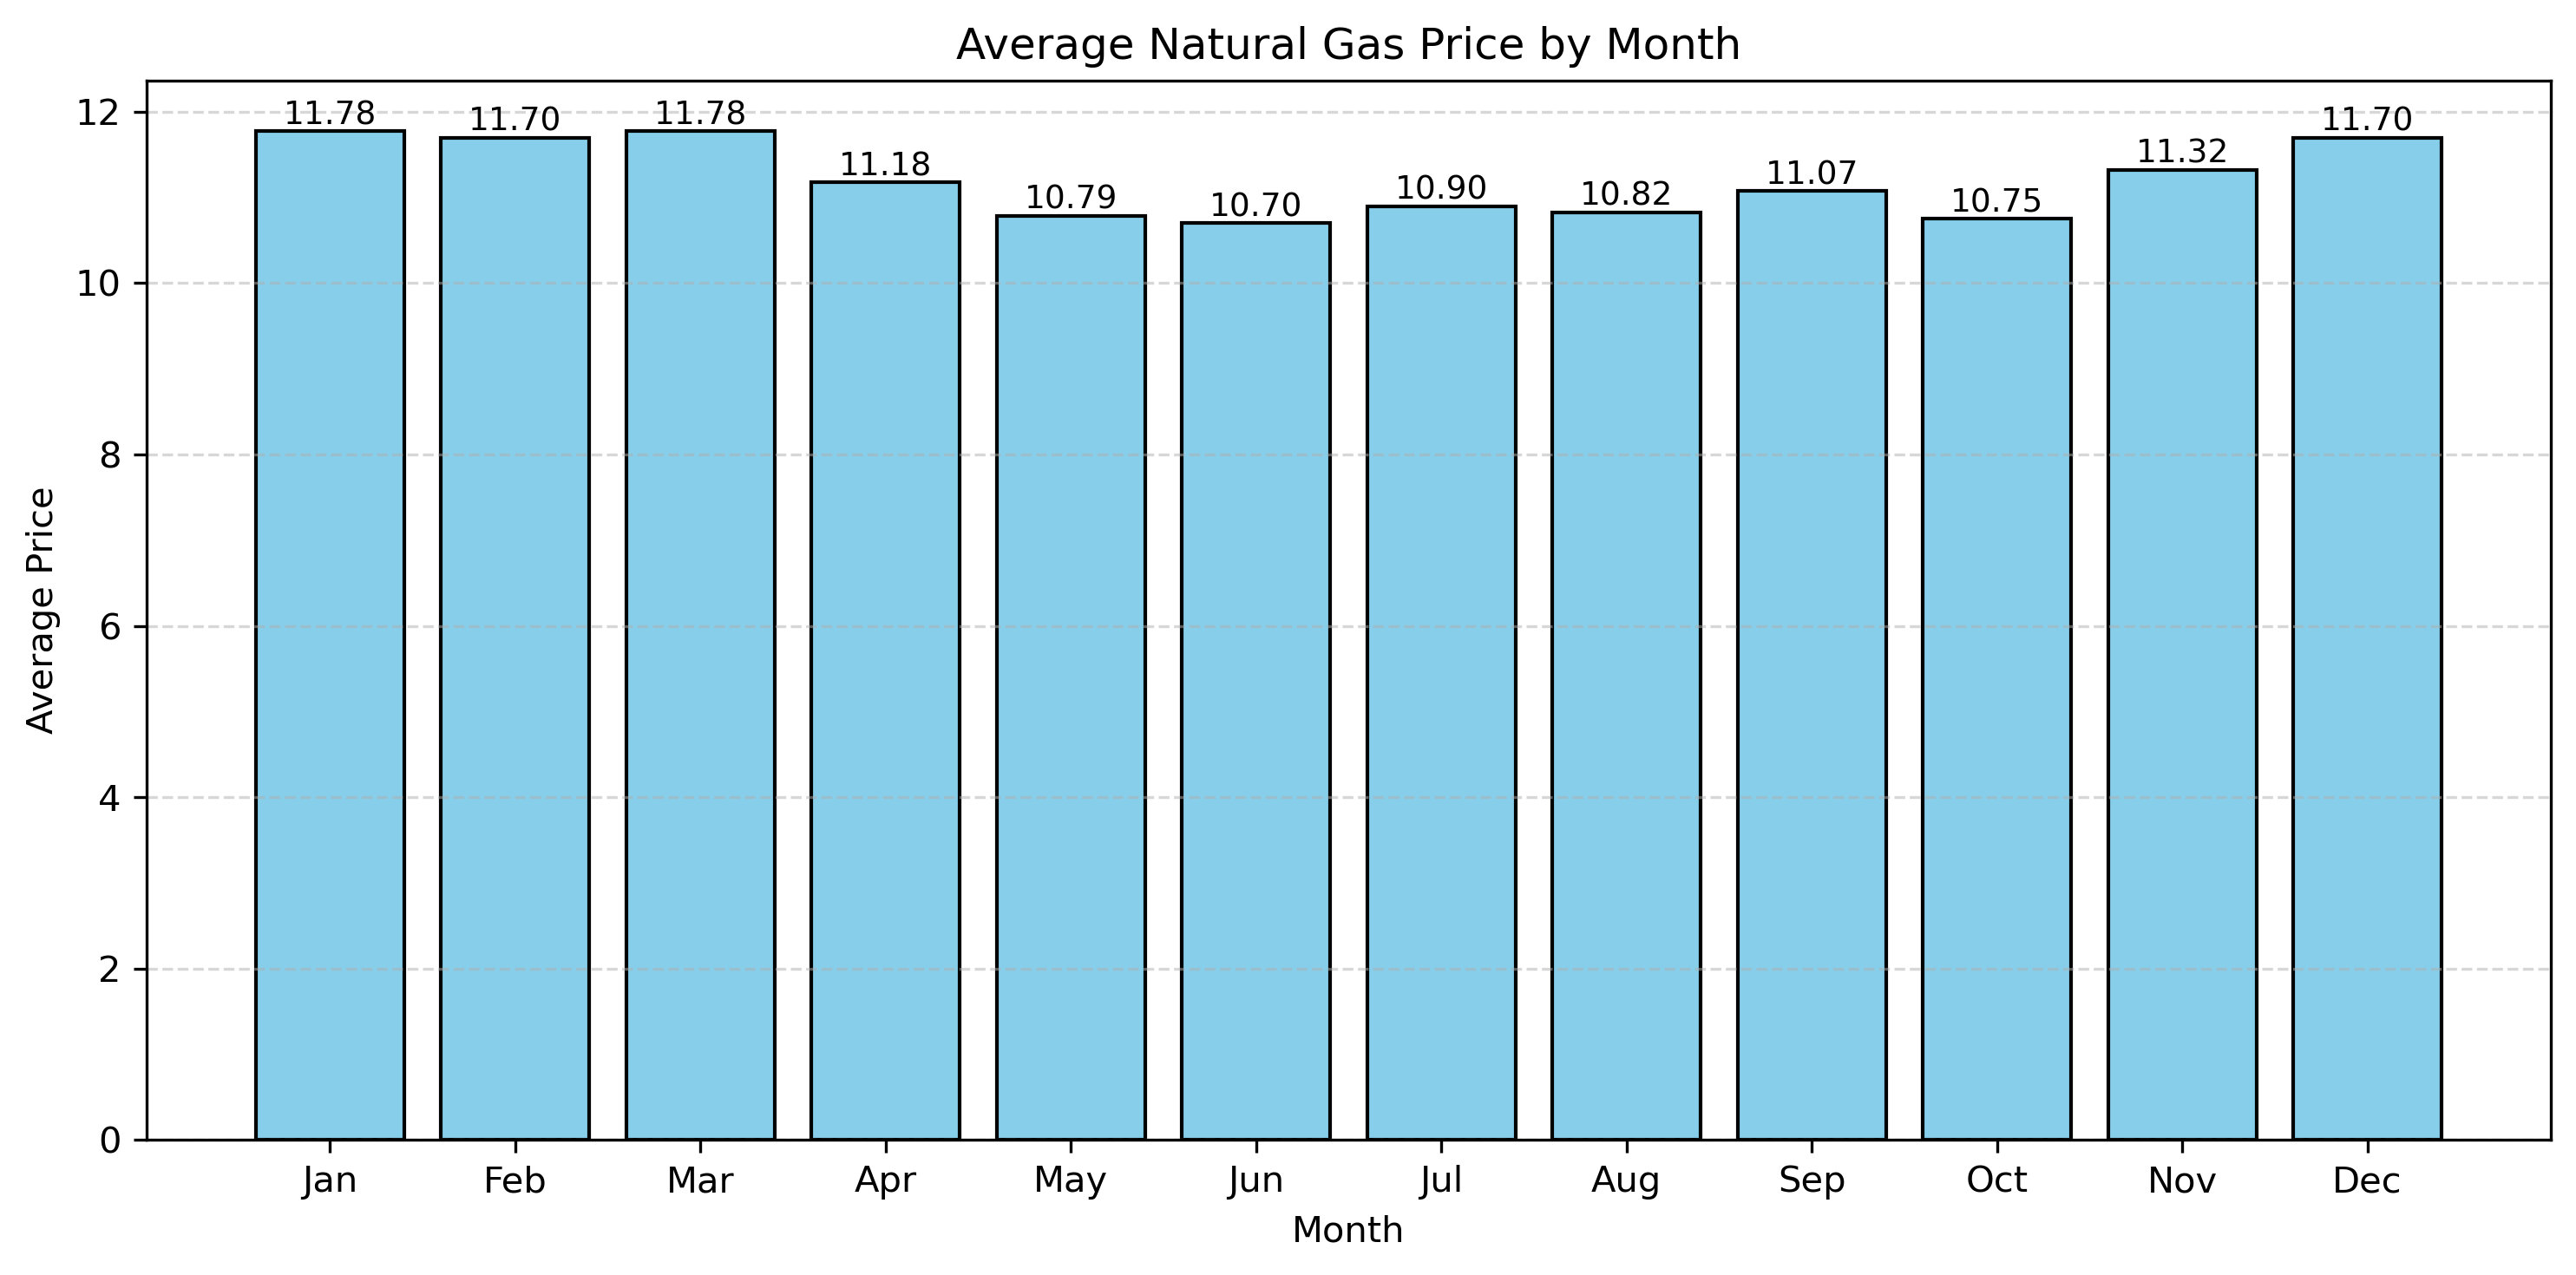

In [36]:
df['Month'] = df.index.month

#group by month and calculate avg price
monthly_avg = df.groupby('Month')['Prices'].mean()

#plotting
fig, ax = plt.subplots(figsize=(10,5),dpi=300)
bars = ax .bar(monthly_avg.index,monthly_avg.values, color='skyblue',edgecolor='black')


# Titles and labels
ax.set_title('Average Natural Gas Price by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Average Price')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.grid(axis='y', linestyle='--', alpha=0.5)


#add labels above the bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2,height,
    f'{height:.2f}', ha = 'center', va = 'bottom'    ,fontsize=9)
    
plt.tight_layout()
plt.show()

Why SARIMA?
The dataset used in this project contains monthly daya from October 2020 to September 2024. This gives us about 48 months of data (4 years).

SARIMA lets us account for both trend and seasonality. As we can see before in the visualizations part, short-term trends (Average Natural Gas Price by Month) and seasonal patterns (Natural Gas Price Over Time) both exist in the dataset. So this makes it ideal for us to use SARIMA in this task.

In [43]:
stepwise_model = auto_arima(df['Prices'],
                            start_p=0, start_q=0,
                            max_p=3, max_q=3,
                            seasonal=True,
                            m=12,
                            start_P=0, start_Q=0,
                            max_P=2, max_Q=2,
                            d=1, D=1,
                            trace=True,
                            error_action='ignore',
                            suppress_warnings=True,
                            stepwise=True)

print(stepwise_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=36.460, Time=0.06 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=21.605, Time=0.07 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=0.43 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=25.917, Time=0.06 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=inf, Time=0.58 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=0.62 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=inf, Time=0.33 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=2.32 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=34.778, Time=0.07 sec
 ARIMA(2,1,0)(1,1,0)[12]             : AIC=15.104, Time=0.16 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=19.665, Time=0.08 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=8.260, Time=0.60 sec
 ARIMA(2,1,0)(2,1,1)[12]             : AIC=inf, Time=1.30 sec
 ARIMA(2,1,0)(1,1,1)[12]             : AIC=inf, Time=0.43 sec
 ARIMA(3,1,0)(2,1,0)[12]             : AIC=9.751, Time=0.65 sec
 ARIM


1. The Best Model
auto_arima gave us this model: ARIMA(2,1,0)(2,1,0)[12]

The first part (ARIMA(2,1,0)) is the non-seasonal component.

p=2: Number of autoregressive (AR) terms. The model uses the previous 2 time points to predict the current one. It assumes the current value depends on it's last 2 values.
d=1: differencing to remove trend. The model uses the change between months, not the actual values. For example, instead of feeding the model actual values (e.g, Oct 2020: 10.1, Nov 2020: 10.3, Dec 2020: 11.0), we feed it the differences between consecutive values (10.3 - 10.1 = 0.2, then 11.0 - 10.3 = 0.7, and so on).
q=0: zero moving average component (no reliance on past errors).
The second part ((2,1,0)[12]) is the seasonal component.

P=2: Seasonal autoregressive (SAR) terms. Model considers values from 12 and 24 months ago.
D=1: one seasonal differencing to remove seasonality.
Q=0: no seasonal MA. No reliance on past errors.
2. Model Selection Criteria
AIC (Akaike Information Criterion) is a statistical measure used for model selection that balances the goodness of fit of a model with its complexity, helping to prevent overfitting. Among all models tested, our best model has the lowest AIC (8.260), which suggests it balances complexity and accuracy.

3. Coefficient Significance
All model coefficients (ar.L1, ar.L2, ar.S.L12, ar.S.L24) but one (sigma2) have p-values < 0.05 which means there's strong evidence that the included parameters are meaningful and significant (not just random noise). This supports the choice of p=2 and P=2.

4. Residual Diagnostics
Good forecasting models have residuals (errors) that behave like white nose: no pattern, constant vatiance, normally distributed.

Skew = -0.14: Skewness measures asymmetry. A value near 0 means the errors are evenly distributed. -0.14 is close to zero so there's no problem.

Kurtosis = 2.47: Kurtosis is a measure of the tailedness of a distribution. The ideal kurtosis (mesokurtic) is 3, and our value indicates slightly lighter tails than a normal distribution (platykurtic). Still quite acceptable.

Heteroskedasticity (H = 0.66, p = 0.48): Heteroskedasticity means the variance of errors changes over time. Null hypothesis: No heteroskedasticity. p = 0.48 → We fail to reject the null → No evidence of heteroskedasticity. This means that the errors have constant variance/spread (homoskedasticity). which is a good thing because it also means that the model is stable and predictions are reliable.

Autocorrelation (Ljung-Box p > 0.05): Residuals show no significant autocorrelation. Which means the model successfully captured all important time-related patterns.

Low AIC, significant coefficients, acceptable skew and kurtosis, no heteroskedasticity, and no autocorrelation. auto_arima has successfully chosen the best model.

In [53]:
df.index.freq = 'M'
model = SARIMAX(df['Prices'],
                order = stepwise_model.order,
                seasonal_order = stepwise_model.seasonal_order)
result = model.fit(disp=False) # disp=False mutes the hidden solver text safely

# THIS WILL FORCE THE OUTPUT TO SHOW:
print(result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                             Prices   No. Observations:                   48
Model:             SARIMAX(2, 1, 0)x(2, 1, 0, 12)   Log Likelihood                   0.870
Date:                            Mon, 25 May 2026   AIC                              8.260
Time:                                    15:36:49   BIC                             16.037
Sample:                                10-31-2020   HQIC                            10.944
                                     - 09-30-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7655      0.185     -4.147      0.000      -1.127      -0.404
ar.L2         -0.4605      0.173   

    Forecast Future prices

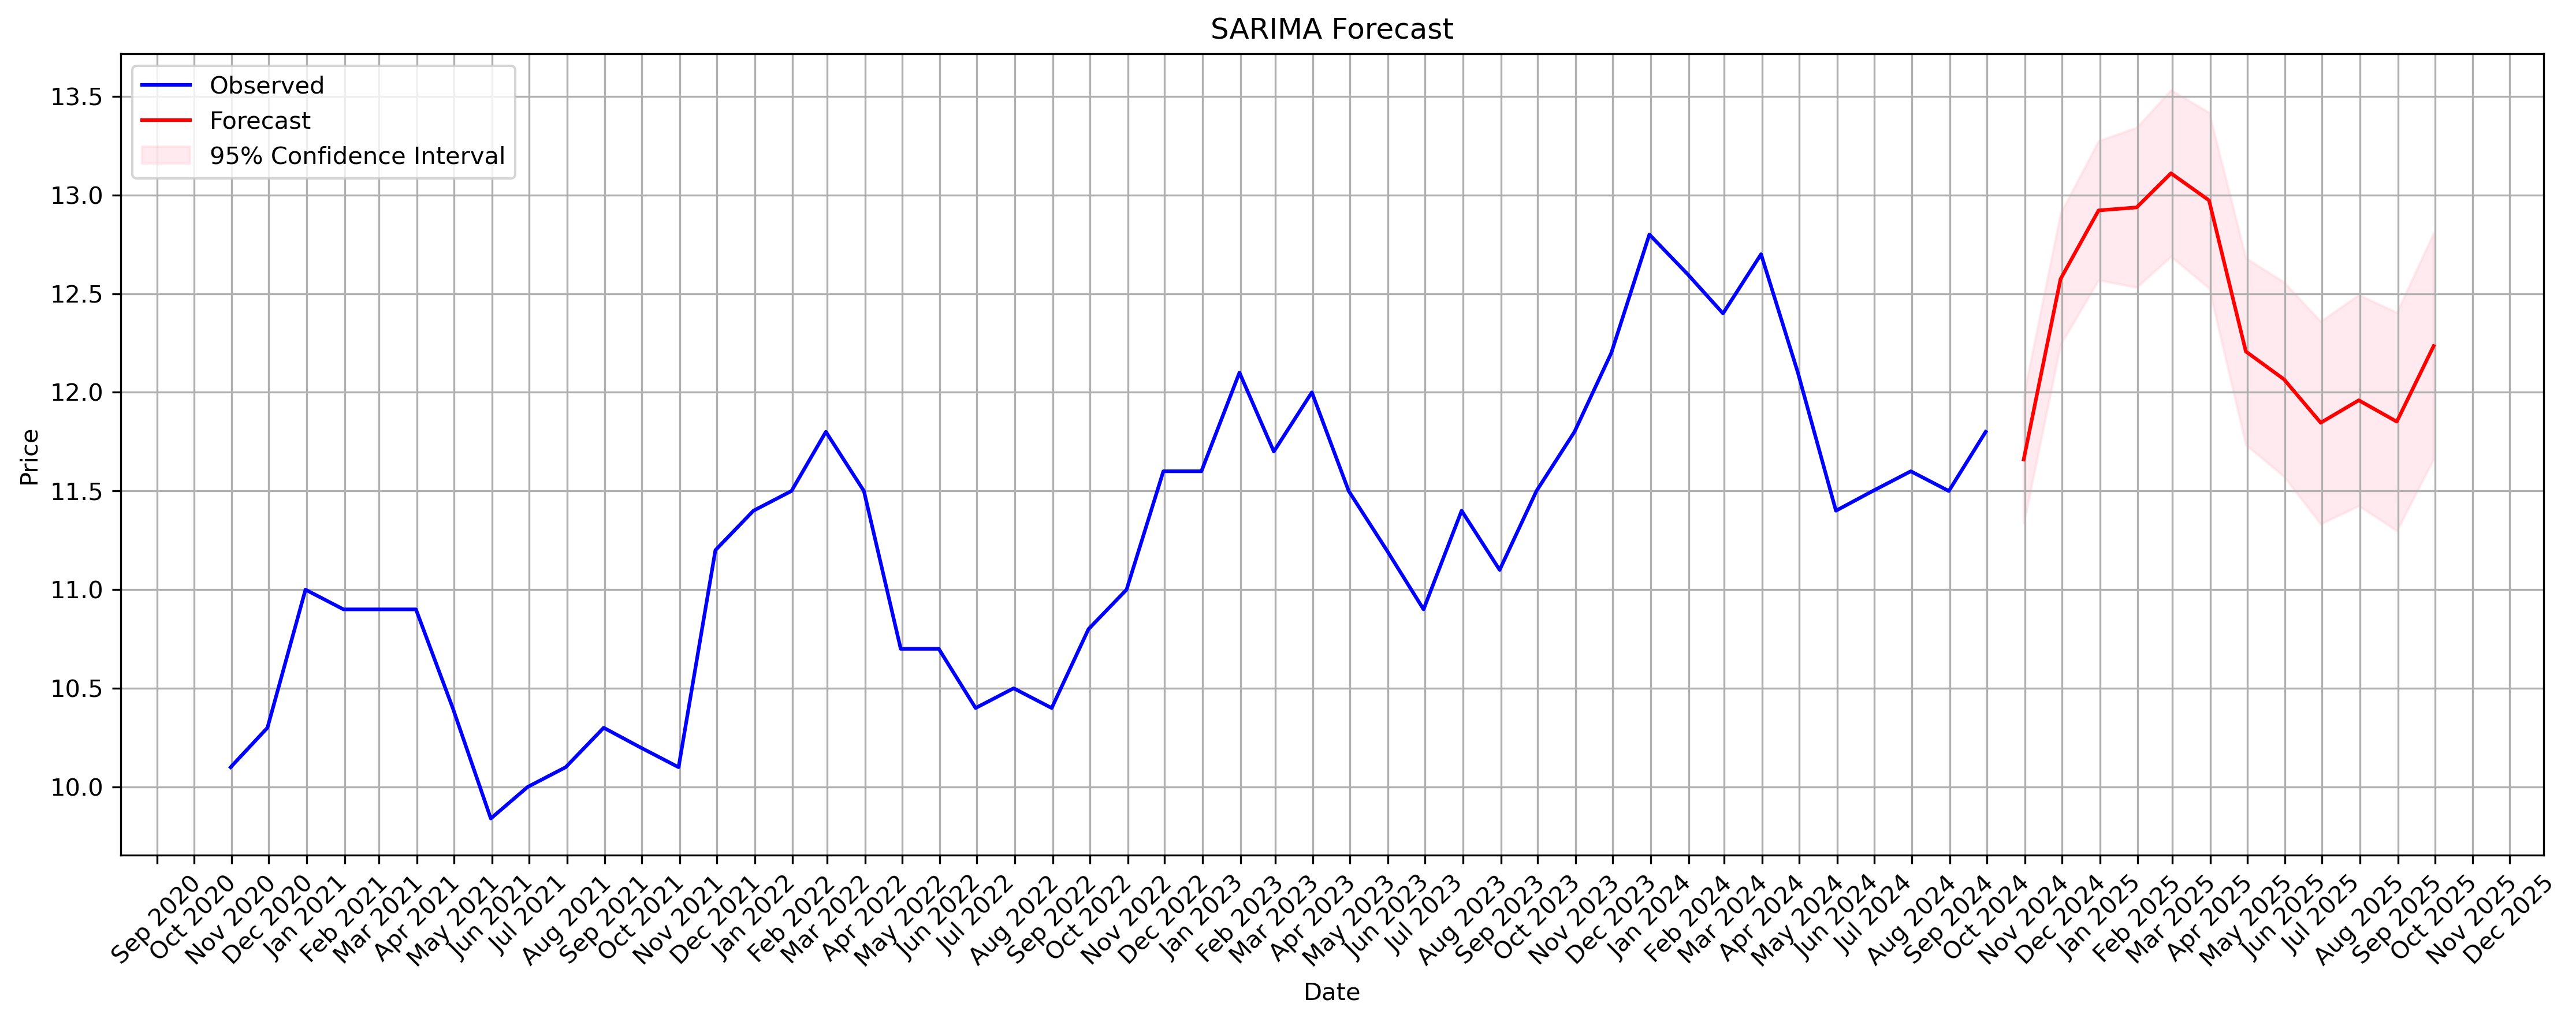

In [54]:
forecast_steps = 12
forecast = result.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

forecast_index = pd.date_range(start=df.index[-1] + pd.offsets.MonthEnd(1), periods=forecast_steps, freq='M')

plt.figure(figsize=(15, 6),dpi=300)
plt.plot(df.index, df['Prices'], label='Observed', color='blue')
plt.plot(forecast_index, forecast_mean, label='Forecast', color='red') 

plt.fill_between(
    forecast_index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='pink',
    alpha=0.3,
    label='95% Confidence Interval'
)

plt.title('SARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

# Format x-axis ticks by month
plt.gca().xaxis.set_major_locator(m_dates.MonthLocator(interval=1))  # one tick per month
plt.gca().xaxis.set_major_formatter(m_dates.DateFormatter('%b %Y'))  # e.g., Jan 2024
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('forecast.png')
plt.show()